# Random Forest aplicado ao preço de abertura da Microsoft

Alvo: `Open` da ação MSFT, em frequência diária.
Período: abril de 2015 a março de 2021.
Split: 80% treino e 20% teste, com corte cronológico.

### Por que diário aqui, se o Holt-Winters usou dados mensais

Random Forest é um modelo supervisionado. Ele não entende tempo, apenas aprende a relação entre
uma tabela de variáveis explicativas e um alvo. Por isso precisa de muitas linhas, e os 72 meses
usados no Holt-Winters seriam insuficientes para treinar centenas de árvores. Com dados diários
temos cerca de 1.500 observações, volume adequado para o método.

### Roteiro

1. Carga dos dados
2. Por que Random Forest precisa de engenharia de variáveis
3. Construção das variáveis explicativas
4. Split cronológico
5. Primeira tentativa: prever o preço diretamente
6. Segunda tentativa: prever a variação do preço
7. Ajuste de hiperparâmetros com validação temporal
8. Modelo final, métricas e benchmark
9. Importância das variáveis
10. Diagnóstico dos erros
11. Conclusões

## 0. Dependências

In [1]:
import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("ambiente pronto")

ambiente pronto


## 1. Carga dos dados

In [2]:
CAMINHO = "Microsoft_Stock.csv"

df = pd.read_csv(CAMINHO)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %H:%M:%S")
df = df.sort_values("Date").set_index("Date")

print(f"pregões : {len(df)}")
print(f"período : {df.index.min():%Y-%m-%d} a {df.index.max():%Y-%m-%d}")
df.head()

pregões : 1511
período : 2015-04-01 a 2021-03-31


,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01 16:00:00,40.6000,40.7600,40.3100,40.7200,36865322
2015-04-02 16:00:00,40.6600,40.7400,40.1200,40.2900,37487476
2015-04-06 16:00:00,40.3400,41.7800,40.1800,41.5500,39223692
2015-04-07 16:00:00,41.6100,41.9100,41.3100,41.5300,28809375
2015-04-08 16:00:00,41.4800,41.6900,41.0400,41.4200,24753438


## 2. Por que Random Forest precisa de engenharia de variáveis

SARIMA e Holt-Winters recebem a série e entendem sozinhos que `y_t` depende de `y_{t-1}`. O
Random Forest não faz isso: para ele cada linha é um caso independente, sem noção de ordem.

Se entregássemos apenas a data, a floresta não teria o que aprender. É preciso transformar a
série em uma tabela supervisionada, onde cada linha representa um dia e as colunas carregam a
informação do passado que já estaria disponível antes da abertura daquele dia.

Daí vem a restrição que organiza a seção seguinte: nada do próprio dia pode entrar. O alvo é o
preço de abertura de hoje, então usar `Close`, `High`, `Low` ou `Volume` de hoje seria vazamento
de dados, já que essa informação só existe depois do fato que queremos prever. Toda variável
leva `.shift(1)`, ou seja, vem do dia anterior.

## 3. Construção das variáveis explicativas

São onze variáveis, todas defasadas em um dia, organizadas por tipo de informação.

| grupo | variáveis | o que captura |
|---|---|---|
| Preço | `open_lag1`, `close_lag1`, `high_lag1`, `low_lag1` | onde o preço estava ontem |
| Retorno | `ret_lag1` | direção e intensidade do último movimento |
| Volatilidade | `range_lag1`, `vol5_lag1` | o quanto o papel está oscilando |
| Liquidez | `logvol_lag1` | volume negociado, em log para reduzir a assimetria |
| Tendência | `ma5_lag1`, `ma20_lag1` | médias móveis de curto e médio prazo |
| Calendário | `dow` | dia da semana |

O `.dropna()` final remove as primeiras vinte linhas, que não têm média móvel de vinte dias
completa.

In [3]:
base = pd.DataFrame(index=df.index)
base["y"] = df["Open"]

base["open_lag1"]   = df["Open"].shift(1)
base["close_lag1"]  = df["Close"].shift(1)
base["high_lag1"]   = df["High"].shift(1)
base["low_lag1"]    = df["Low"].shift(1)
base["ret_lag1"]    = df["Close"].pct_change().shift(1)
base["range_lag1"]  = (df["High"] - df["Low"]).shift(1)
base["vol5_lag1"]   = df["Close"].pct_change().rolling(5).std().shift(1)
base["logvol_lag1"] = np.log(df["Volume"]).shift(1)
base["ma5_lag1"]    = df["Close"].rolling(5).mean().shift(1)
base["ma20_lag1"]   = df["Close"].rolling(20).mean().shift(1)
base["dow"]         = base.index.dayofweek

base = base.dropna()
FEATURES = [c for c in base.columns if c != "y"]

print(f"linhas após limpeza : {len(base)}")
print(f"variáveis           : {len(FEATURES)}")
base.head(3)

linhas após limpeza : 1491
variáveis           : 11


,y,open_lag1,close_lag1,high_lag1,low_lag1,ret_lag1,range_lag1,vol5_lag1,logvol_lag1,ma5_lag1,ma20_lag1,dow
Date,,,,,,,,,,,,
2015-04-30 16:00:00,48.7000,48.7200,49.0600,49.3100,48.5000,-0.0020,0.8100,0.0441,17.6826,47.4920,43.2080,3
2015-05-01 16:00:00,48.5800,48.7000,48.6400,49.5400,48.6000,-0.0086,0.9400,0.0465,17.9857,48.5520,43.6040,4
2015-05-04 16:00:00,48.3700,48.5800,48.6600,48.8800,48.4000,0.0004,0.4800,0.0121,17.4775,48.7100,44.0225,0


## 4. Split cronológico

A divisão é de 80% para treino e 20% para teste, em ordem de tempo, igual à usada no trabalho de
SARIMAX.

O `train_test_split` aleatório está descartado por um motivo específico. Embaralhar colocaria
dias de 2021 no treino e dias de 2016 no teste, fazendo o modelo prever o passado com
conhecimento do futuro. O resultado pareceria excelente e seria inútil. Em série temporal o teste
precisa ser sempre o trecho final.

In [4]:
corte = int(len(base) * 0.8)
treino, teste = base.iloc[:corte], base.iloc[corte:]

print(f"treino : {len(treino)} dias | {treino.index.min():%Y-%m-%d} a {treino.index.max():%Y-%m-%d}")
print(f"teste  : {len(teste)} dias | {teste.index.min():%Y-%m-%d} a {teste.index.max():%Y-%m-%d}")
print()
print(f"faixa de preço no treino : US$ {treino['y'].min():,.2f} a US$ {treino['y'].max():,.2f}")
print(f"faixa de preço no teste  : US$ {teste['y'].min():,.2f} a US$ {teste['y'].max():,.2f}")

treino : 1192 dias | 2015-04-30 a 2020-01-23
teste  : 299 dias | 2020-01-24 a 2021-03-31

faixa de preço no treino : US$ 40.45 a US$ 167.42
faixa de preço no teste  : US$ 137.01 a US$ 245.03


Antes de seguir, um detalhe que volta a importar na próxima seção: o treino termina em US$ 167 e
o teste chega a US$ 245. Boa parte do período de teste tem preços que nunca apareceram durante o
treino.

## 5. Primeira tentativa: prever o preço diretamente

O caminho intuitivo é definir o alvo como o `Open` de hoje e as variáveis como as onze colunas
defasadas. Vamos treinar e observar o resultado.

In [5]:
def metricas(real, previsto):
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    return {
        "MAE": mean_absolute_error(real, previsto),
        "RMSE": float(np.sqrt(mean_squared_error(real, previsto))),
        "MAPE_%": float(np.mean(np.abs((real - previsto) / real)) * 100),
    }

rf_nivel = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_nivel.fit(treino[FEATURES], treino["y"])
prev_nivel = rf_nivel.predict(teste[FEATURES])

print(metricas(teste["y"], prev_nivel))
print()
print(f"maior preço previsto pelo modelo : US$ {prev_nivel.max():,.2f}")
print(f"maior preço visto no treino      : US$ {treino['y'].max():,.2f}")
print(f"maior preço real no teste        : US$ {teste['y'].max():,.2f}")

{'MAE': 37.73013913043458, 'RMSE': 43.6826347761573, 'MAPE_%': 17.53249863854225}

maior preço previsto pelo modelo : US$ 166.71
maior preço visto no treino      : US$ 167.42
maior preço real no teste        : US$ 245.03


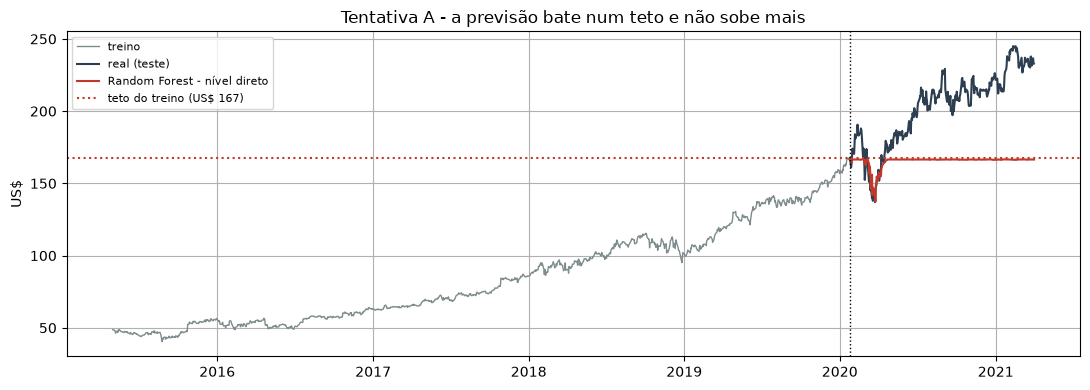

In [6]:
fig, ax = plt.subplots()
ax.plot(treino.index, treino["y"], color="#7f8c8d", lw=1, label="treino")
ax.plot(teste.index, teste["y"], color="#2c3e50", lw=1.5, label="real (teste)")
ax.plot(teste.index, prev_nivel, color="#c0392b", lw=1.5, label="Random Forest - nível direto")
ax.axhline(treino["y"].max(), color="#c0392b", ls=":", lw=1.5,
           label=f"teto do treino (US$ {treino['y'].max():,.0f})")
ax.axvline(teste.index[0], color="black", ls=":", lw=1)
ax.set_title("Tentativa A - a previsão bate num teto e não sobe mais")
ax.set_ylabel("US$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Por que a previsão trava

O gráfico mostra a previsão presa a uma linha horizontal assim que a ação ultrapassa o valor
máximo observado no treino.

A razão é estrutural. Uma árvore de decisão prevê calculando a média dos valores de treino que
caíram em cada folha, e a média de um conjunto de números nunca pode ser maior que o maior deles.
A consequência é que o Random Forest não extrapola: sua previsão fica matematicamente presa ao
intervalo entre o mínimo e o máximo vistos no treino.

Em uma série com tendência de alta persistente, como o preço de uma ação, essa limitação é fatal.
O modelo nunca consegue acompanhar níveis novos. O MAE de cerca de US$ 38 mede o tamanho da alta
que o modelo foi incapaz de representar, e não um erro de ajuste.

É a mesma magnitude de erro observada nos benchmarks do trabalho de SARIMAX, pela mesma razão de
fundo: previsão presa a um nível antigo.

## 6. Segunda tentativa: prever a variação

A solução padrão é mudar o alvo. Em vez de pedir o preço, pedimos a diferença:

```
alvo = Open_de_hoje - Close_de_ontem
```

E depois reconstruímos o preço:

```
previsão_de_preço = Close_de_ontem + variação_prevista
```

A razão de isso funcionar é que a variação diária oscila em torno de zero na mesma faixa durante
todo o período, sem tendência. O Random Forest passa a trabalhar sobre um alvo estacionário, onde
a incapacidade de extrapolar deixa de ser um problema, e o nível do preço entra pela soma e não
pela floresta.

É o mesmo papel que a diferenciação (`d=1`) cumpre no SARIMA, feito manualmente.

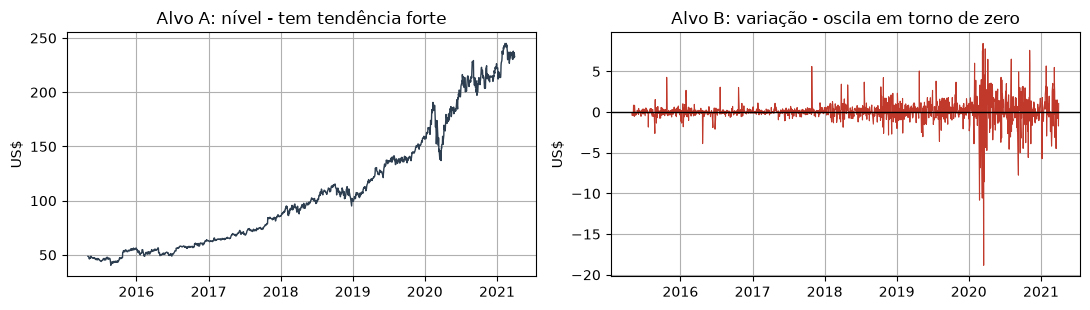

variação - média no treino : US$ 0.0865
variação - média no teste  : US$ 0.1251
variação - faixa no treino : US$ -3.87 a US$ 5.61
variação - faixa no teste  : US$ -18.83 a US$ 8.44


In [7]:
alvo_treino = treino["y"] - treino["close_lag1"]
alvo_teste  = teste["y"] - teste["close_lag1"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(base.index, base["y"], color="#2c3e50", lw=1)
axes[0].set_title("Alvo A: nível - tem tendência forte")
axes[0].set_ylabel("US$")
axes[1].plot(base.index, base["y"] - base["close_lag1"], color="#c0392b", lw=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Alvo B: variação - oscila em torno de zero")
axes[1].set_ylabel("US$")
plt.tight_layout()
plt.show()

print(f"variação - média no treino : US$ {alvo_treino.mean():,.4f}")
print(f"variação - média no teste  : US$ {alvo_teste.mean():,.4f}")
print(f"variação - faixa no treino : US$ {alvo_treino.min():,.2f} a US$ {alvo_treino.max():,.2f}")
print(f"variação - faixa no teste  : US$ {alvo_teste.min():,.2f} a US$ {alvo_teste.max():,.2f}")

### Leitura

A diferença entre os dois gráficos é o ponto da seção. O primeiro alvo sobe indefinidamente,
enquanto o segundo oscila em torno de zero e mantém média parecida no treino, US$ 0,09, e no
teste, US$ 0,13. Sem tendência não há níveis novos a extrapolar, e o modelo pode operar dentro
da faixa que conhece.

Uma ressalva, porém. A faixa do teste, de -18,83 a +8,44, extrapola a do treino, de -3,87 a
+5,61. Isso não invalida a abordagem, porque são pouquíssimos dias extremos, todos concentrados
no crash da COVID em março de 2020. No dia típico a variação está bem dentro do observado. Mas é
exatamente nesses dias que o modelo acumula seus maiores erros, como o diagnóstico final mostra.

## 7. Ajuste de hiperparâmetros com validação temporal

A grade é pequena e justificada, variando os quatro parâmetros que mais afetam o comportamento da
floresta.

| parâmetro | valores | o que controla |
|---|---|---|
| `n_estimators` | 200, 500 | número de árvores; mais árvores estabilizam, com custo de tempo |
| `max_depth` | None, 6, 12 | profundidade; raso generaliza mais, profundo tende a decorar |
| `min_samples_leaf` | 2, 10 | mínimo de observações por folha; valor alto suaviza a previsão |
| `max_features` | `"sqrt"`, `1.0` | variáveis sorteadas por divisão; `sqrt` aumenta a diversidade entre árvores |

O total é de 24 combinações.

A validação usa `TimeSeriesSplit` com cinco cortes. Diferente do K-Fold comum, ele sempre treina
no passado e valida no futuro, respeitando a ordem temporal. O critério de escolha é o MAE médio
nos cinco cortes.

In [8]:
GRADE = {
    "n_estimators": [200, 500],
    "max_depth": [None, 6, 12],
    "min_samples_leaf": [2, 10],
    "max_features": ["sqrt", 1.0],
}
combinacoes = [dict(zip(GRADE, v)) for v in itertools.product(*GRADE.values())]

X_tr = treino[FEATURES]
cv = TimeSeriesSplit(n_splits=5)

linhas = []
for params in combinacoes:
    scores = []
    for idx_tr, idx_val in cv.split(X_tr):
        m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        m.fit(X_tr.iloc[idx_tr], alvo_treino.iloc[idx_tr])
        scores.append(mean_absolute_error(alvo_treino.iloc[idx_val], m.predict(X_tr.iloc[idx_val])))
    linhas.append({**params, "MAE_cv": float(np.mean(scores))})

busca = pd.DataFrame(linhas).sort_values("MAE_cv").reset_index(drop=True)
print(f"combinações testadas: {len(busca)}")
busca.head(5)

combinações testadas: 24


,n_estimators,max_depth,min_samples_leaf,max_features,MAE_cv
0,500,6.0000,10,sqrt,0.4845
1,200,6.0000,10,sqrt,0.4849
2,500,NaN,10,sqrt,0.4852
3,500,12.0000,10,sqrt,0.4853
4,200,NaN,10,sqrt,0.4854


### Leitura

As cinco melhores combinações ficam praticamente empatadas, com diferença na quarta casa decimal,
mas dois padrões aparecem de forma consistente.

O primeiro é que `max_features="sqrt"` domina o topo do ranking. Sortear poucas variáveis por
divisão deixa as árvores mais diferentes entre si, e é dessa diversidade que vem o ganho do
ensemble.

O segundo é que `min_samples_leaf=10` supera o valor 2. Folhas maiores produzem previsões mais
suaves, e com dados financeiros ruidosos folhas pequenas acabam memorizando ruído.

O próprio empate no topo é informativo: o problema é tão dominado por ruído que o ajuste fino dos
hiperparâmetros pouco altera o resultado.

## 8. Modelo final, métricas e benchmark

Treinamos a melhor configuração em todo o conjunto de treino e reconstruímos o preço somando a
variação prevista ao fechamento do dia anterior.

O benchmark escolhido é o `Close` de ontem, o palpite mais direto possível para o preço de
abertura de hoje, sem usar modelo algum. Se o Random Forest não superar esse valor, toda a
engenharia de variáveis e o ajuste de hiperparâmetros não entregaram valor.

In [9]:
melhores = busca.drop(columns="MAE_cv").iloc[0].to_dict()
melhores["n_estimators"] = int(melhores["n_estimators"])
melhores["min_samples_leaf"] = int(melhores["min_samples_leaf"])
melhores["max_depth"] = None if pd.isna(melhores["max_depth"]) else int(melhores["max_depth"])
print("configuracao escolhida:", melhores)

rf = RandomForestRegressor(random_state=42, n_jobs=-1, **melhores)
rf.fit(treino[FEATURES], alvo_treino)

prev_rf = teste["close_lag1"].values + rf.predict(teste[FEATURES])
prev_naive = teste["close_lag1"].values

comparacao = pd.DataFrame(
    {
        "Random Forest (variação)": metricas(teste["y"], prev_rf),
        "Benchmark: Close de ontem": metricas(teste["y"], prev_naive),
        "Random Forest (nível direto)": metricas(teste["y"], prev_nivel),
    }
).T
comparacao

configuracao escolhida: {'n_estimators': 500, 'max_depth': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt'}


,MAE,RMSE,MAPE_%
Random Forest (variação),1.8863,2.8367,1.0060
Benchmark: Close de ontem,1.8996,2.8422,1.0125
Random Forest (nível direto),37.7301,43.6826,17.5325


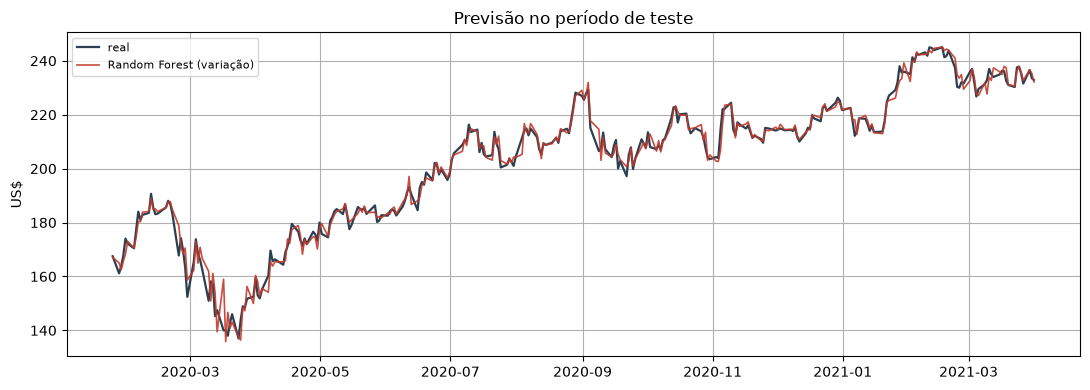

ganho de MAE sobre o benchmark: US$ 0.0133
em termos relativos           : 0.70%


In [10]:
fig, ax = plt.subplots()
ax.plot(teste.index, teste["y"], color="#2c3e50", lw=1.6, label="real")
ax.plot(teste.index, prev_rf, color="#c0392b", lw=1.2, alpha=0.9, label="Random Forest (variação)")
ax.set_title("Previsão no período de teste")
ax.set_ylabel("US$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ganho = (metricas(teste["y"], prev_naive)["MAE"] - metricas(teste["y"], prev_rf)["MAE"])
print(f"ganho de MAE sobre o benchmark: US$ {ganho:,.4f}")
print(f"em termos relativos           : {ganho / metricas(teste['y'], prev_naive)['MAE'] * 100:,.2f}%")

### Leitura

Trocar o alvo levou o MAE de cerca de US$ 38 para cerca de US$ 1,89, uma redução próxima de 95%.
A mudança de formulação valeu muito mais do que qualquer ajuste de hiperparâmetro.

O ganho sobre o benchmark, porém, é de apenas 0,7%, o equivalente a cerca de um centavo de MAE.
Onze variáveis, quinhentas árvores e vinte e quatro combinações testadas produziram uma melhoria
que na prática é indistinguível de simplesmente chutar o fechamento de ontem.

Esse resultado era esperado. A variação diária do preço de uma ação é essencialmente imprevisível
a partir do histórico recente. É a mesma conclusão a que o Holt-Winters chegou por outro caminho,
ao estimar alfa próximo de 1 e desligar tendência e sazonalidade.

## 9. Importância das variáveis

O Random Forest mede quanto cada variável contribuiu para reduzir o erro nas divisões das
árvores. Quanto maior o valor, mais o modelo se apoiou naquela variável.

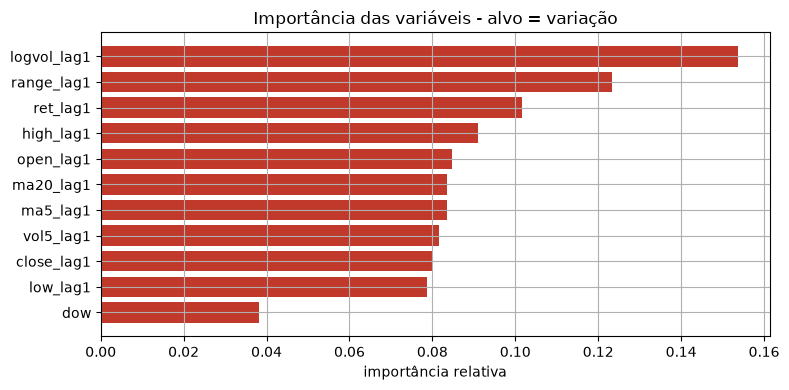

,importancia
logvol_lag1,0.1537
range_lag1,0.1233
ret_lag1,0.1016
high_lag1,0.0910
open_lag1,0.0847
ma20_lag1,0.0836
ma5_lag1,0.0835
vol5_lag1,0.0815
close_lag1,0.0802
low_lag1,0.0788


In [11]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp.index, imp.values, color="#c0392b")
ax.set_title("Importância das variáveis - alvo = variação")
ax.set_xlabel("importância relativa")
plt.tight_layout()
plt.show()

imp.sort_values(ascending=False).to_frame("importancia")

### Leitura

O ranking difere bastante do que a intuição sugeriria, e é coerente com a teoria.

No topo aparecem volume, amplitude e retorno, ou seja, `logvol_lag1`, `range_lag1` e `ret_lag1`.
São variáveis que medem agitação do mercado, não o preço em si.

As variáveis de preço ficam no meio do ranking. Para prever a variação, saber que a ação custava
US$ 150 ontem pouco ajuda; o que importa é o quanto ela estava se movimentando.

O dia da semana fica em último lugar. Não há efeito de calendário relevante, o que confirma o que
o Holt-Winters já havia indicado ao estimar gama igual a 0.

O contraste com a primeira tentativa é informativo: lá `close_lag1` sozinho concentrava mais da
metade da importância, porque o modelo estava apenas copiando o nível de ontem.

## 10. Validação walk-forward (janela expansiva)

Nas seções anteriores o Random Forest foi ajustado uma única vez, nos 80% iniciais, e
nunca mais viu um dado novo: as 299 previsões do teste saíram todas da mesma floresta
estimada em janeiro de 2020.

Em operação a rotina é outra. Todo pregão o valor real do dia anterior é observado,
entra na base e o modelo é reajustado de tempos em tempos. A validação walk-forward
reproduz essa dinâmica.

Como foi implementado:

1. Janela expansiva. O histórico começa nos 80% de treino e cresce um dia a cada passo.
   Nenhuma observação futura entra no ajuste, então a avaliação continua fora da amostra.
2. Horizonte de um passo. Em cada iteração o modelo prevê apenas o próximo pregão.
3. Reestimação a cada 14 passos. Reajustar a floresta todos os dias custaria 299 treinos
   e mudaria pouco o resultado, porque as importâncias se movem devagar. A cada 14 pregões,
   cerca de três semanas de bolsa, a floresta é treinada do zero com todo o histórico
   disponível até ali.
4. O benchmark passa pelo mesmo protocolo, para a comparação ser feita com os dois
   modelos recebendo a mesma informação.

Uma observação honesta antes dos números: como todas as variáveis de entrada já são
defasadas em um pregão, a avaliação estática desta base já era, de fato, uma previsão de
um passo à frente. A diferença entre os dois protocolos aqui não é o horizonte, é apenas
o reaproveitamento dos dados novos no treino. Por isso não se deve esperar uma mudança
grande, diferente do que acontece com modelos univariados como o SARIMA e o Holt-Winters,
que no horizonte fixo degeneram em uma reta.

In [12]:
# ---------- Validação walk-forward: Random Forest sobre a variação ----------
import time

PASSOS_REFIT = 14
TAM_TESTE = len(teste)

print(f"Observações de treino inicial     : {len(treino)} "
      f"({treino.index.min():%Y-%m-%d} a {treino.index.max():%Y-%m-%d})")
print(f"Observações de teste walk-forward : {TAM_TESTE} "
      f"({teste.index.min():%Y-%m-%d} a {teste.index.max():%Y-%m-%d})")
print(f"Reestimação completa a cada {PASSOS_REFIT} passos")

alvo_total = base["y"] - base["close_lag1"]

inicio_wf = time.time()

rf_wf = RandomForestRegressor(random_state=42, n_jobs=-1, **melhores)
rf_wf.fit(base[FEATURES].iloc[:corte], alvo_total.iloc[:corte])

wf_pred, wf_real, wf_datas = [], [], []
n_refits = 1

for i in range(TAM_TESTE):
    linha = teste.iloc[i:i + 1]
    variacao = float(rf_wf.predict(linha[FEATURES])[0])

    wf_pred.append(float(linha["close_lag1"].iloc[0]) + variacao)
    wf_real.append(float(linha["y"].iloc[0]))
    wf_datas.append(teste.index[i])

    if (i + 1) % PASSOS_REFIT == 0 or (i + 1) == TAM_TESTE:
        fim = corte + i + 1
        rf_wf.fit(base[FEATURES].iloc[:fim], alvo_total.iloc[:fim])
        n_refits += 1

elapsed_wf = time.time() - inicio_wf
wf_pred = np.asarray(wf_pred, dtype=float)
wf_real = np.asarray(wf_real, dtype=float)

print(f"\nValidação walk-forward concluída em {elapsed_wf:.2f} segundos "
      f"com {len(wf_datas)} previsões geradas e {n_refits} reestimações.")

Observações de treino inicial     : 1192 (2015-04-30 a 2020-01-23)
Observações de teste walk-forward : 299 (2020-01-24 a 2021-03-31)
Reestimação completa a cada 14 passos



Validação walk-forward concluída em 9.06 segundos com 299 previsões geradas e 23 reestimações.


In [13]:
# ---------- Horizonte estático contra walk-forward ----------
comp_wf = pd.DataFrame(
    {
        "Estático (um único ajuste)": [
            metricas(teste["y"], prev_rf)["MAE"],
            metricas(teste["y"], prev_naive)["MAE"],
        ],
        "Walk-forward (reajuste a cada 14)": [
            metricas(wf_real, wf_pred)["MAE"],
            metricas(wf_real, teste["close_lag1"].values)["MAE"],
        ],
    },
    index=["Random Forest (variação)", "Benchmark: Close de ontem"],
)
display(comp_wf.round(4))

tabela_wf = pd.DataFrame(
    {
        "Random Forest (walk-forward)": metricas(wf_real, wf_pred),
        "Benchmark: Close de ontem": metricas(wf_real, teste["close_lag1"].values),
        "Random Forest (estático)": metricas(teste["y"], prev_rf),
    }
).T
display(tabela_wf.round(4))

ganho_wf = metricas(wf_real, teste["close_lag1"].values)["MAE"] - metricas(wf_real, wf_pred)["MAE"]
print(f"ganho do walk-forward sobre o benchmark : US$ {ganho_wf:,.4f}")

,Estático (um único ajuste),Walk-forward (reajuste a cada 14)
Random Forest (variação),1.8863,1.9583
Benchmark: Close de ontem,1.8996,1.8996


,MAE,RMSE,MAPE_%
Random Forest (walk-forward),1.9583,2.9177,1.0390
Benchmark: Close de ontem,1.8996,2.8422,1.0125
Random Forest (estático),1.8863,2.8367,1.0060


ganho do walk-forward sobre o benchmark : US$ -0.0588


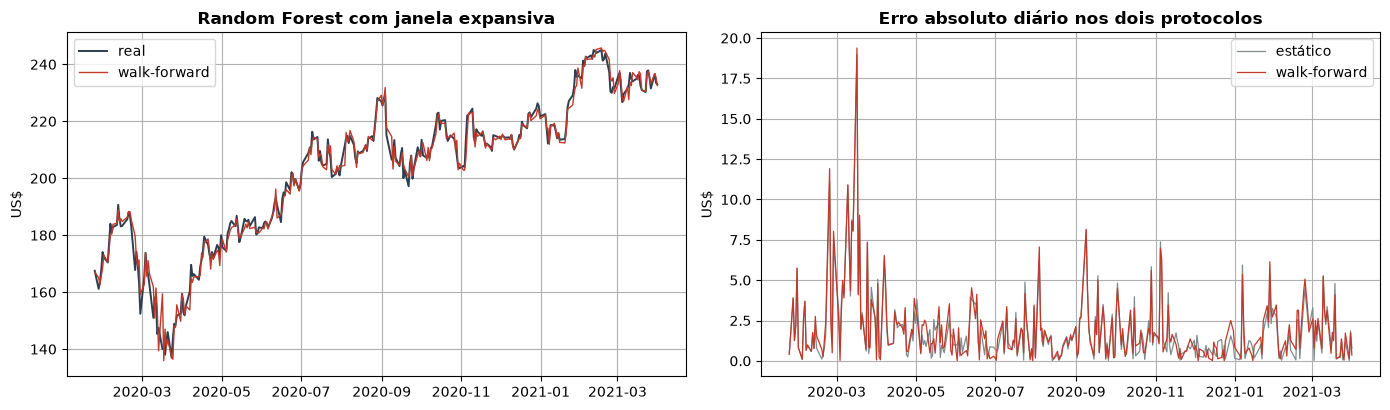

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].plot(wf_datas, wf_real, color="#2c3e50", lw=1.4, label="real")
axes[0].plot(wf_datas, wf_pred, color="#c0392b", lw=1.0, label="walk-forward")
axes[0].set_title("Random Forest com janela expansiva", weight="bold")
axes[0].set_ylabel("US$")
axes[0].legend()

erro_est = teste["y"].values - prev_rf
erro_wf = wf_real - wf_pred
axes[1].plot(wf_datas, np.abs(erro_est), color="#7f8c8d", lw=0.9, label="estático")
axes[1].plot(wf_datas, np.abs(erro_wf), color="#c0392b", lw=0.9, label="walk-forward")
axes[1].set_title("Erro absoluto diário nos dois protocolos", weight="bold")
axes[1].set_ylabel("US$")
axes[1].legend()

plt.tight_layout()
plt.show()

### Leitura

O resultado contraria a expectativa inicial: o reajuste periódico piorou o erro, de
US$ 1,8863 no protocolo estático para US$ 1,9583 sob walk-forward, uma deterioração de
cerca de 3,8%. Sob esse protocolo o Random Forest também perde para o benchmark do
fechamento anterior, que fica em US$ 1,8996.

A explicação está no que entra no treino a cada reajuste. O período de teste começa em
janeiro de 2020 e contém o choque de março daquele ano, com variações diárias de até
dezoito dólares, contra uma faixa de menos de seis dólares em todo o treino original.
A partir do primeiro reajuste posterior ao choque, esses dias extremos passam a compor
as folhas das árvores e deslocam as médias que o modelo usa para prever dias comuns.
Como o MAE é dominado pelos dias comuns, que são a maioria, a floresta fica pior
justamente onde ela mais pesa na métrica.

Esse é um efeito conhecido em modelos baseados em média condicional: incorporar um regime
novo sem sinalizar a mudança de regime contamina a previsão do regime antigo. As saídas
usuais seriam ponderar as observações por recência, usar janela deslizante em vez de
expansiva, ou incluir uma variável que identifique o período de volatilidade alta.
Nenhuma delas foi aplicada aqui porque o objetivo da seção é medir o protocolo, não
otimizar o modelo.

A conclusão prática é que janela expansiva não é automaticamente melhor. Ela é mais
realista, porque reproduz a rotina de produção, mas quando o período de teste contém uma
quebra estrutural o retreino pode custar precisão. O que o walk-forward entrega aqui é
uma estimativa mais honesta do que o modelo faria em operação, e essa estimativa é pior
do que a do protocolo estático.

## 11. Diagnóstico dos erros

Erro é o valor real menos o previsto, no período de teste. Procuramos duas coisas: ausência de
viés, com erro médio próximo de zero, e entendimento de onde o modelo mais erra.

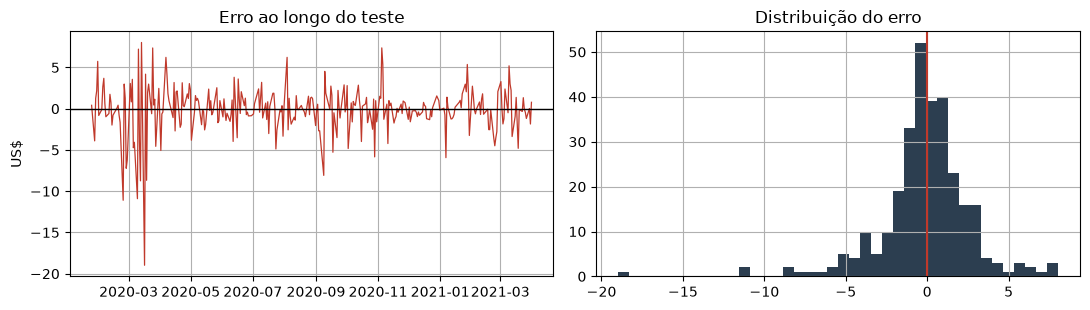

viés (erro médio)  : US$ -0.1396
desvio padrão      : US$ 2.8333
maior erro         : US$ 18.9755 em 2020-03-16


In [15]:
erro = teste["y"].values - prev_rf

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(teste.index, erro, color="#c0392b", lw=0.9)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Erro ao longo do teste")
axes[0].set_ylabel("US$")
axes[1].hist(erro, bins=40, color="#2c3e50")
axes[1].axvline(0, color="#c0392b", lw=1.5)
axes[1].set_title("Distribuição do erro")
plt.tight_layout()
plt.show()

pior = int(np.argmax(np.abs(erro)))
print(f"viés (erro médio)  : US$ {erro.mean():,.4f}")
print(f"desvio padrão      : US$ {erro.std():,.4f}")
print(f"maior erro         : US$ {np.abs(erro).max():,.4f} em {teste.index[pior]:%Y-%m-%d}")

### Leitura

O erro médio é praticamente zero, o que indica ausência de viés sistemático: o modelo não erra
consistentemente para cima nem para baixo. A distribuição é concentrada em torno de zero, com
caudas longas.

Essas caudas se concentram em março de 2020, durante o crash da COVID. Naqueles dias a ação abriu
com grandes saltos em relação ao fechamento anterior, e nenhuma variável construída a partir do
histórico recente poderia antecipar isso. É a limitação esperada do método: ele aprende o
comportamento típico, não choques externos.

## 12. Conclusões

### Sobre o método

O Random Forest não lê séries temporais nativamente. Foi necessário transformar a série em tabela
supervisionada, com onze variáveis defasadas em um dia para evitar vazamento de dados.

A limitação mais relevante encontrada foi a incapacidade de extrapolar. Como cada previsão é a
média de valores vistos no treino, o modelo ficou travado no teto de US$ 167 e acumulou MAE de
cerca de US$ 38 em uma série que chegou a US$ 245.

A correção foi mudar o alvo de nível para variação e reconstruir o preço em seguida. O MAE caiu
cerca de 95%, para US$ 1,89. A formulação do problema importou muito mais do que o ajuste do
modelo.

A validação usou `TimeSeriesSplit`, que preserva a ordem temporal. Um K-Fold embaralhado teria
produzido um resultado otimista e inválido.

### Sobre a série

O ganho sobre o benchmark do `Close` de ontem foi de apenas 0,7%, cerca de um centavo de MAE.
A engenharia de variáveis e o ajuste de hiperparâmetros quase não adicionaram poder preditivo.

As variáveis mais úteis foram as de volume e volatilidade, e não as de preço. Para prever
variação, o que importa é o nível de agitação do mercado.

O dia da semana foi a variável menos importante, reforçando a ausência de sazonalidade já
detectada no trabalho de Holt-Winters.

### O que isso significa na prática

O Random Forest foi aplicado corretamente e superou o palpite ingênuo, ainda que por margem
mínima. O experimento mostra que um modelo mais flexível não resolve um problema sem sinal. Para
preços de ações, a melhor previsão continua sendo essencialmente o último valor observado.

O método seria muito mais adequado em problemas com relações não lineares estáveis e alvo dentro
de uma faixa conhecida, como risco de crédito, previsão de demanda ou churn, e não em
extrapolação de séries com tendência.